In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib

import os
import numpy as np

import hdbscan

from src.colors import colors_new_legend, generate_colors

In [2]:
variables_path = "data/variables"
figures_path = "data/figures"
berenslab_data_path = "data/embeddings"

In [3]:
tsne = np.load(os.path.join(variables_path, "tsne_reparsed.npy"))

=====> cluster_size=400,min_samples=6
num of clusters 14


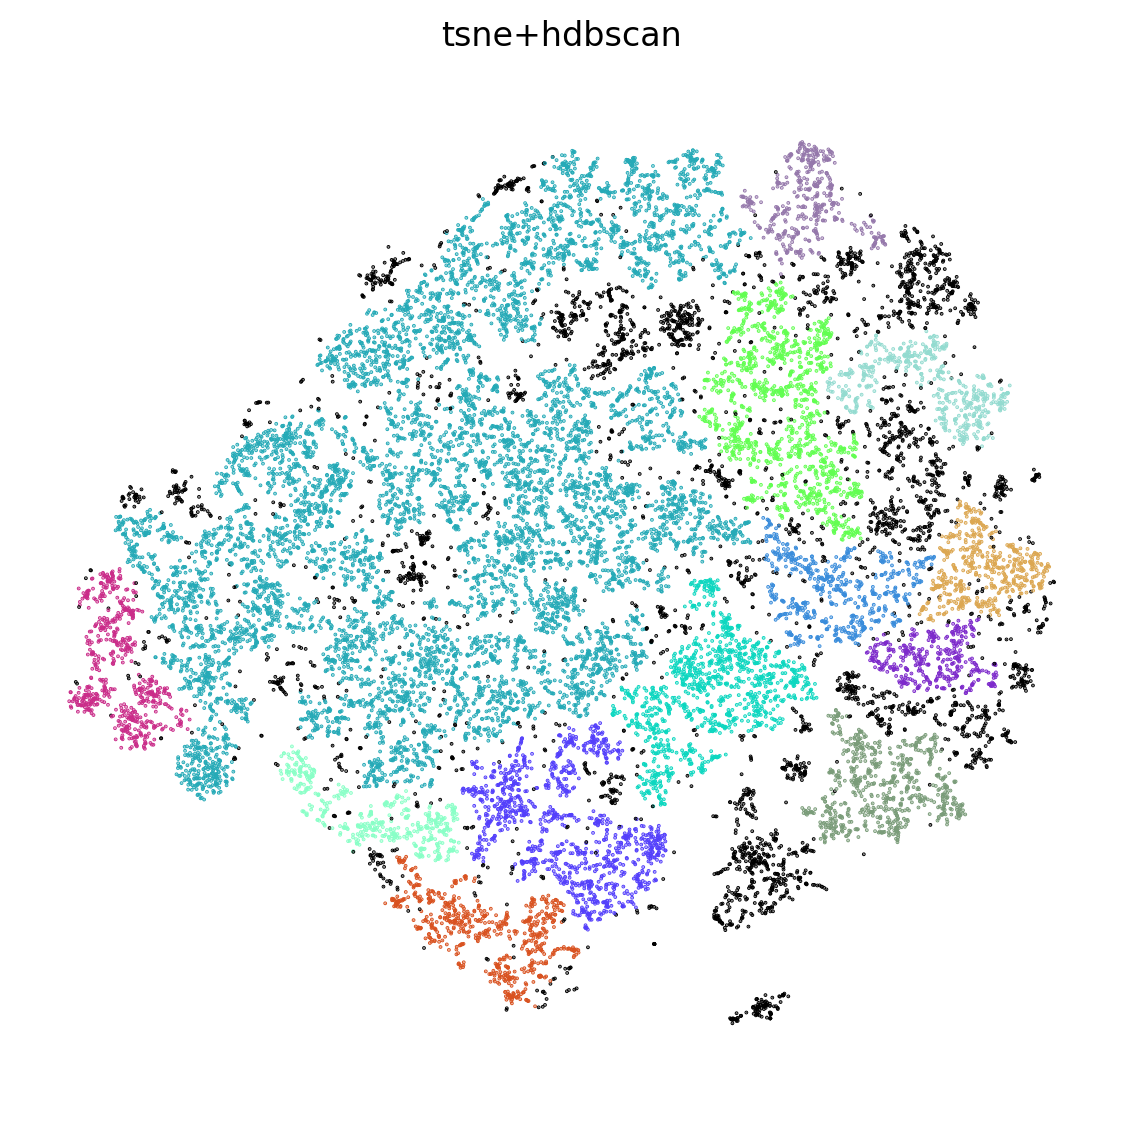

In [4]:
cluster_sizes = [400]
num_samples = [6]

for cluster_size in cluster_sizes:
    for num_sample in num_samples:
        print(f"=====> cluster_size={cluster_size},min_samples={num_sample}")

        hdbscanModel = hdbscan.HDBSCAN(
            min_cluster_size=cluster_size, min_samples=num_sample
        ).fit(tsne)

        labels = hdbscanModel.labels_
        print("num of clusters", len(np.unique(hdbscanModel.labels_)))
        if len(np.unique(hdbscanModel.labels_)) < 10:
            continue

        colors_new_legend = generate_colors(
            len(np.unique(hdbscanModel.labels_))
        )
        colors = [colors_new_legend[i] for i in labels]

        fig, ax = plt.subplots(
            figsize=(5.5, 5.5), dpi=200, layout="constrained"
        )
        ax.scatter(
            tsne[:, 0],
            tsne[:, 1],
            s=0.5,
            c=colors,
            marker=".",
        )
        ax.axis("equal")
        ax.grid()
        ax.axis("off")
        ax.set_title("tsne+hdbscan")
        plt.show()
        
        fig.savefig('data/results/tsne-hdbscan.png')